<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **SpaceX  Falcon 9 First Stage Landing Prediction**


 ## Hands-on Lab: Complete the EDA with Visualization


Estimated time needed: **70** minutes


In this assignment, we will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is due to the fact that SpaceX can reuse the first stage. 

In this lab, you will perform Exploratory Data Analysis and Feature Engineering.


Falcon 9 first stage will land successfully


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planned. Space X performs a controlled landing in the oceans. 


  ## Objectives
Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

- Exploratory Data Analysis
- Preparing Data  Feature Engineering 


----


Install the below libraries


### Import Libraries and Define Auxiliary Functions


We will import the following libraries the lab 



In [1]:
# andas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

## Exploratory Data Analysis 


First, let's read the SpaceX dataset into a Pandas dataframe and print its summary


In [2]:
df=pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# If you were unable to complete the previous lab correctly you can uncomment and load this csv

# df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/dataset_part_2.csv')

df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [7]:
# Inspección de columnas para verificar nomenclatura profesional
print("Columnas disponibles:", df.columns.tolist())
print(df.head(1))

Columnas disponibles: ['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'Class']
   FlightNumber        Date BoosterVersion  PayloadMass Orbit    LaunchSite  \
0             1  2010-06-04       Falcon 9  6104.959412   LEO  CCAFS SLC 40   

     Outcome  Flights  GridFins  Reused   Legs LandingPad  Block  ReusedCount  \
0  None None        1     False   False  False        NaN    1.0            0   

  Serial  Longitude   Latitude  Class  
0  B0003 -80.577366  28.561857      0  


First, let's try to see how the `FlightNumber` (indicating the continuous launch attempts.) and `Payload` variables would affect the launch outcome.

We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass is also important; it seems the more massive the payload, the less likely the first stage will return.


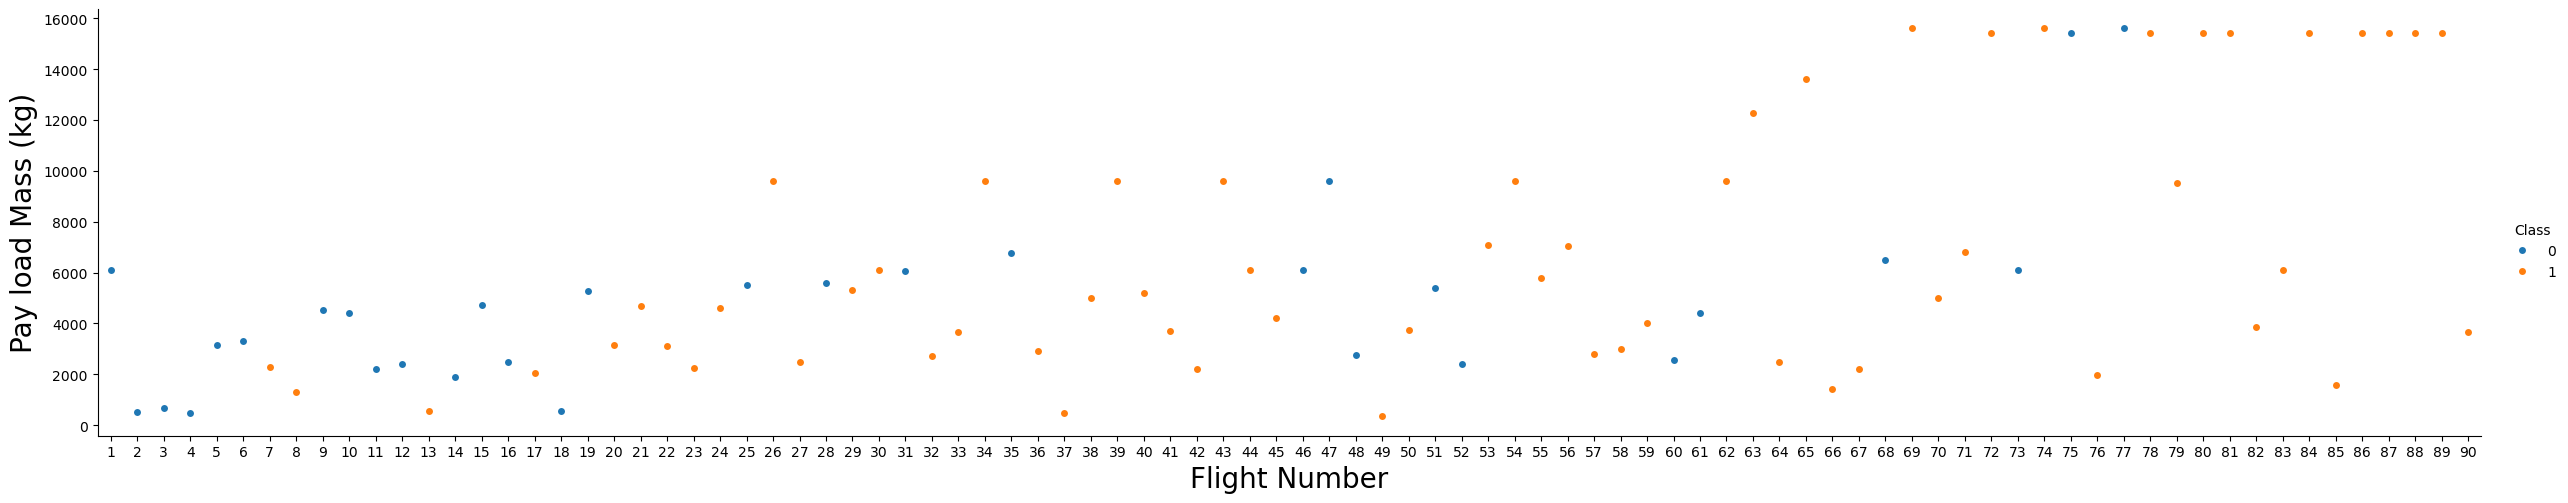

In [3]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

Next, let's drill down to each site visualize its detailed launch records.


### TASK 1: Visualize the relationship between Flight Number and Launch Site


Use the function <code>catplot</code> to plot <code>FlightNumber</code> vs <code>LaunchSite</code>, set the  parameter <code>x</code>  parameter to <code>FlightNumber</code>,set the  <code>y</code> to <code>Launch Site</code> and set the parameter <code>hue</code> to <code>'class'</code>


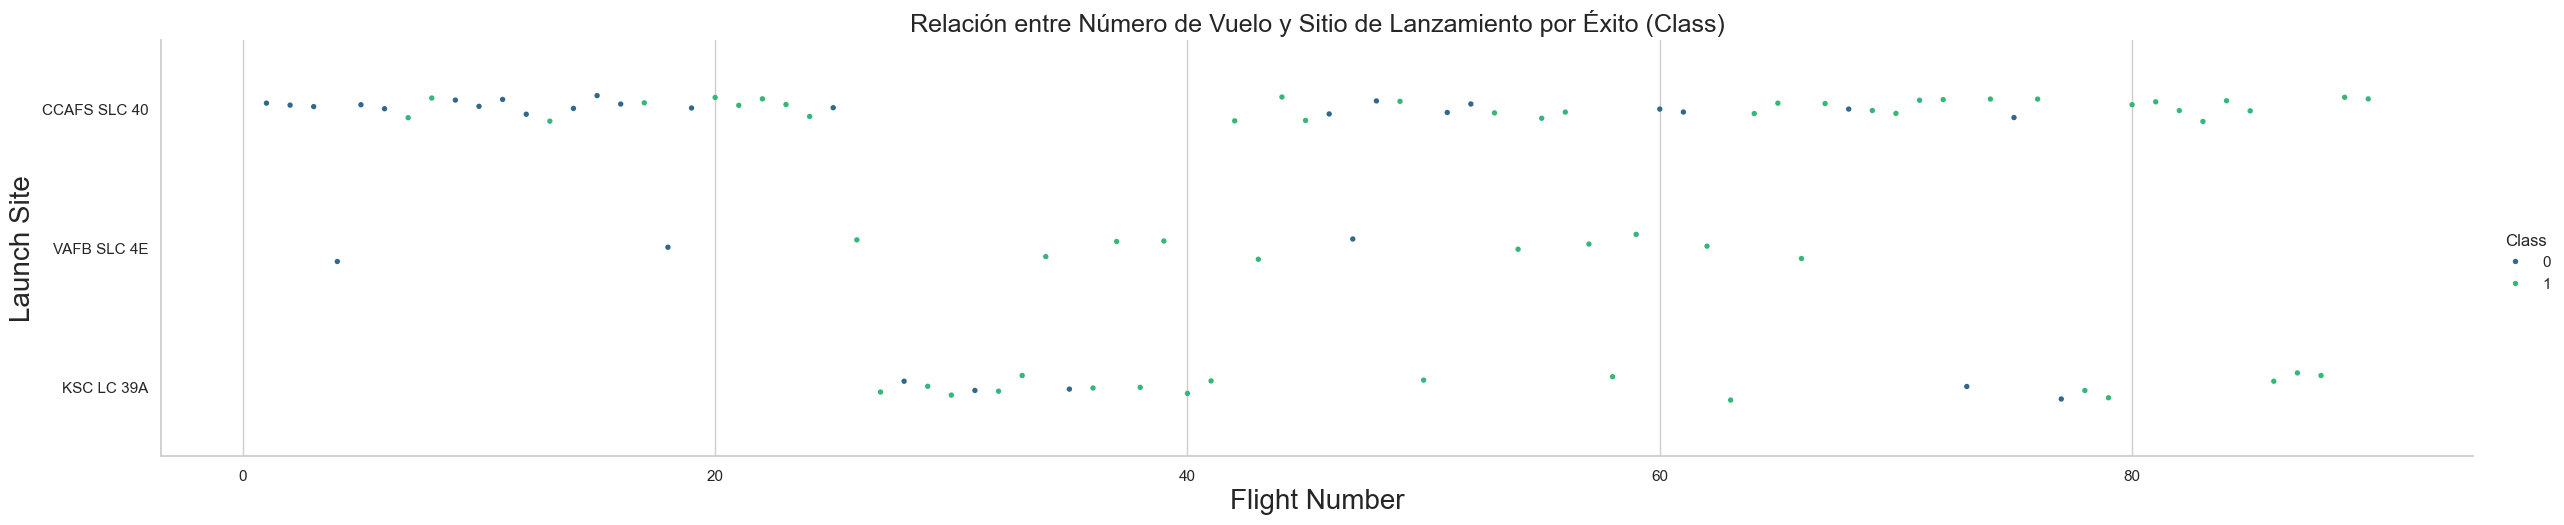

In [8]:
sns.catplot(
    data=df,
    x="FlightNumber",
    y="LaunchSite",
    hue="Class",
    aspect=5,
    height=5,
    s=15,          # Aumentamos ligeramente el tamaño para mejor visibilidad
    palette="viridis" # Una paleta con mejor contraste para daltónicos y publicaciones
)

# 3. Refinamiento de etiquetas con el estándar de visualización científica
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.title("Relación entre Número de Vuelo y Sitio de Lanzamiento por Éxito (Class)", fontsize=18)

plt.show()

Now try to explain the patterns you found in the Flight Number vs. Launch Site scatter point plots.


### TASK 2: Visualize the relationship between Payload and Launch Site


We also want to observe if there is any relationship between launch sites and their payload mass.


/tmp/ipykernel_15639/1100372344.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Class (0=Fail, 1=Success)", title_fontsize='15',


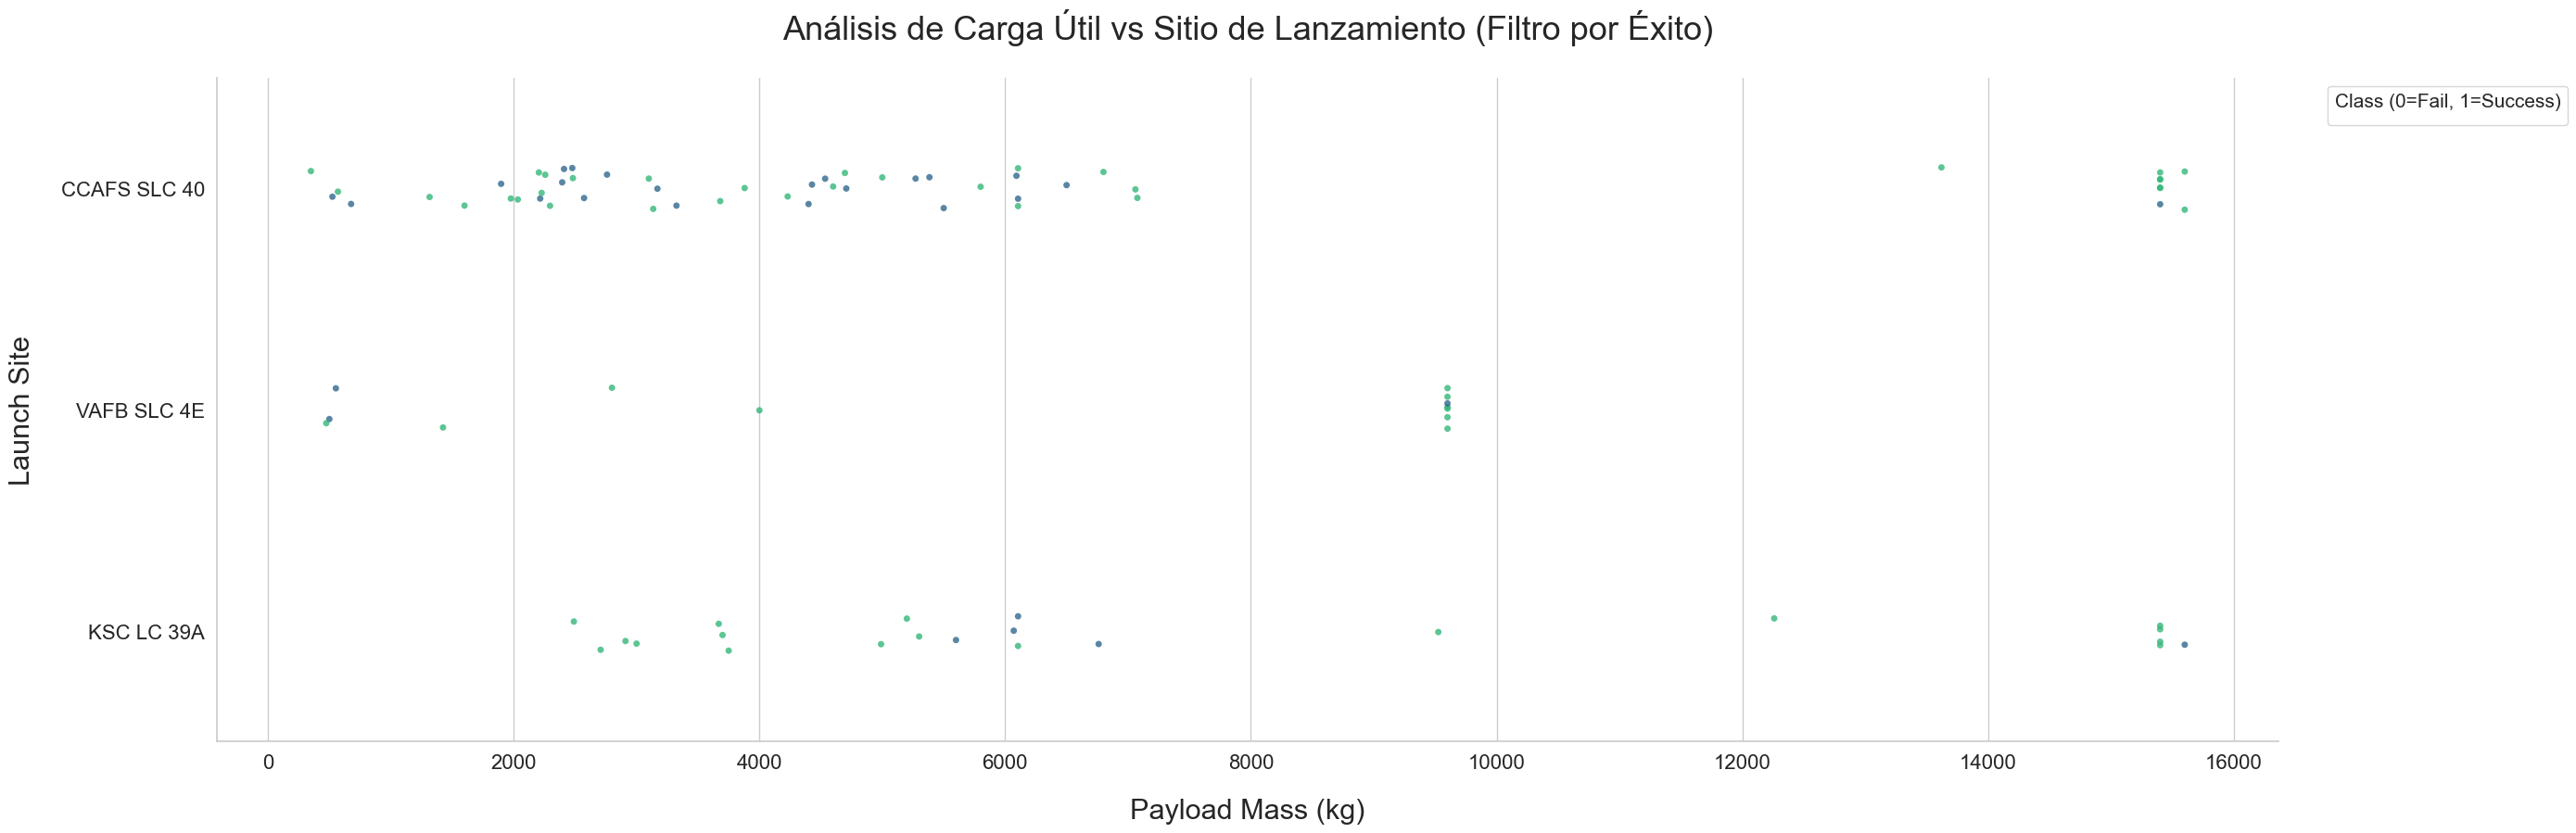

In [10]:

sns.set_context("talk") # Configura automáticamente fuentes grandes para presentaciones
sns.set_theme(style="whitegrid")

# 2. Generación del gráfico con dimensiones extendidas
# height=10 (el doble de lo anterior) y aspect=3 para un ancho total masivo
g = sns.catplot(
    data=df, 
    x="PayloadMass", 
    y="LaunchSite", 
    hue="Class", 
    aspect=3,       # Ratio ancho/alto
    height=8,       # Altura en pulgadas
    s=25,           # Puntos mucho más grandes y visibles
    alpha=0.8,      # Opacidad alta para definir bien el color
    palette="viridis",
    legend=False    # La gestionaremos manualmente para que no estorbe
)

# 3. Refinamiento de etiquetas con tamaños específicos (Rigor PEP8)
plt.xlabel("Payload Mass (kg)", fontsize=22, labelpad=20)
plt.ylabel("Launch Site", fontsize=22, labelpad=20)
plt.title("Análisis de Carga Útil vs Sitio de Lanzamiento (Filtro por Éxito)", fontsize=26, pad=30)

# Ajuste de los ticks de los ejes
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Posicionamos la leyenda fuera para que no tape los datos
plt.legend(title="Class (0=Fail, 1=Success)", title_fontsize='15', 
           fontsize='13', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.show()

Now if you observe Payload Vs. Launch Site scatter point chart you will find for the VAFB-SLC  launchsite there are no  rockets  launched for  heavypayload mass(greater than 10000).


### TASK  3: Visualize the relationship between success rate of each orbit type


Next, we want to visually check if there are any relationship between success rate and orbit type.


Let's create a `bar chart` for the sucess rate of each orbit


/tmp/ipykernel_15639/176253853.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


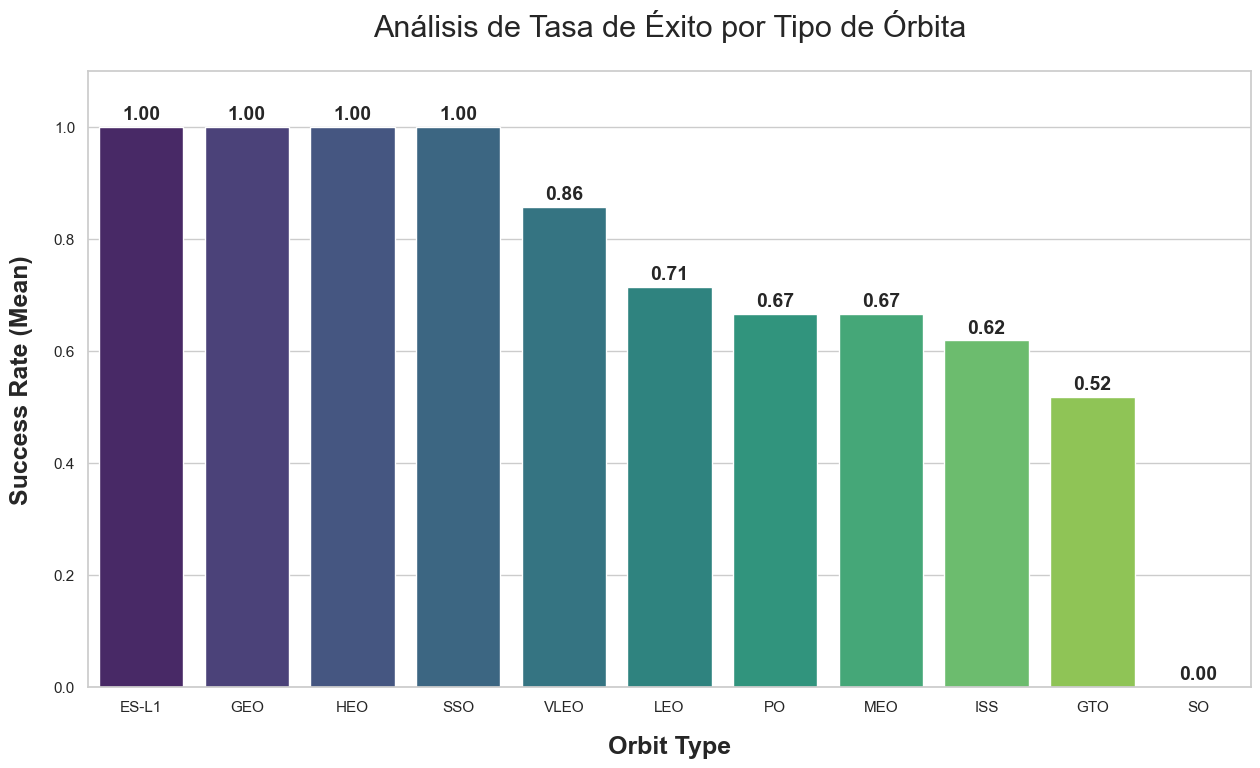

In [12]:
# HINT use groupby method on Orbit column and get the mean of Class column

# 1. Aplicación del HINT: Groupby y Mean de Class
# Ordenamos los valores para cumplir con el estándar de análisis de datos
orbit_success = df.groupby("Orbit")["Class"].mean().sort_values(ascending=False).reset_index()

# 2. Configuración de estética profesional
sns.set_context("talk")
sns.set_theme(style="whitegrid")

# 3. Generación del Bar Chart (Tamaño Extendido)
plt.figure(figsize=(15, 8))
barplot = sns.barplot(
    data=orbit_success,
    x="Orbit",
    y="Class",
    palette="viridis"
)

# 4. Refinamiento de metadatos y etiquetas
plt.xlabel("Orbit Type", fontsize=18, fontweight='bold', labelpad=15)
plt.ylabel("Success Rate (Mean)", fontsize=18, fontweight='bold', labelpad=15)
plt.title("Análisis de Tasa de Éxito por Tipo de Órbita", fontsize=22, pad=25)

# Añadimos etiquetas de valor sobre las barras para mayor precisión
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=14, fontweight='bold')

plt.ylim(0, 1.1)  # Margen para las etiquetas superiores
plt.show()

Analyze the ploted bar chart try to find which orbits have high sucess rate.


### TASK  4: Visualize the relationship between FlightNumber and Orbit type


For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.


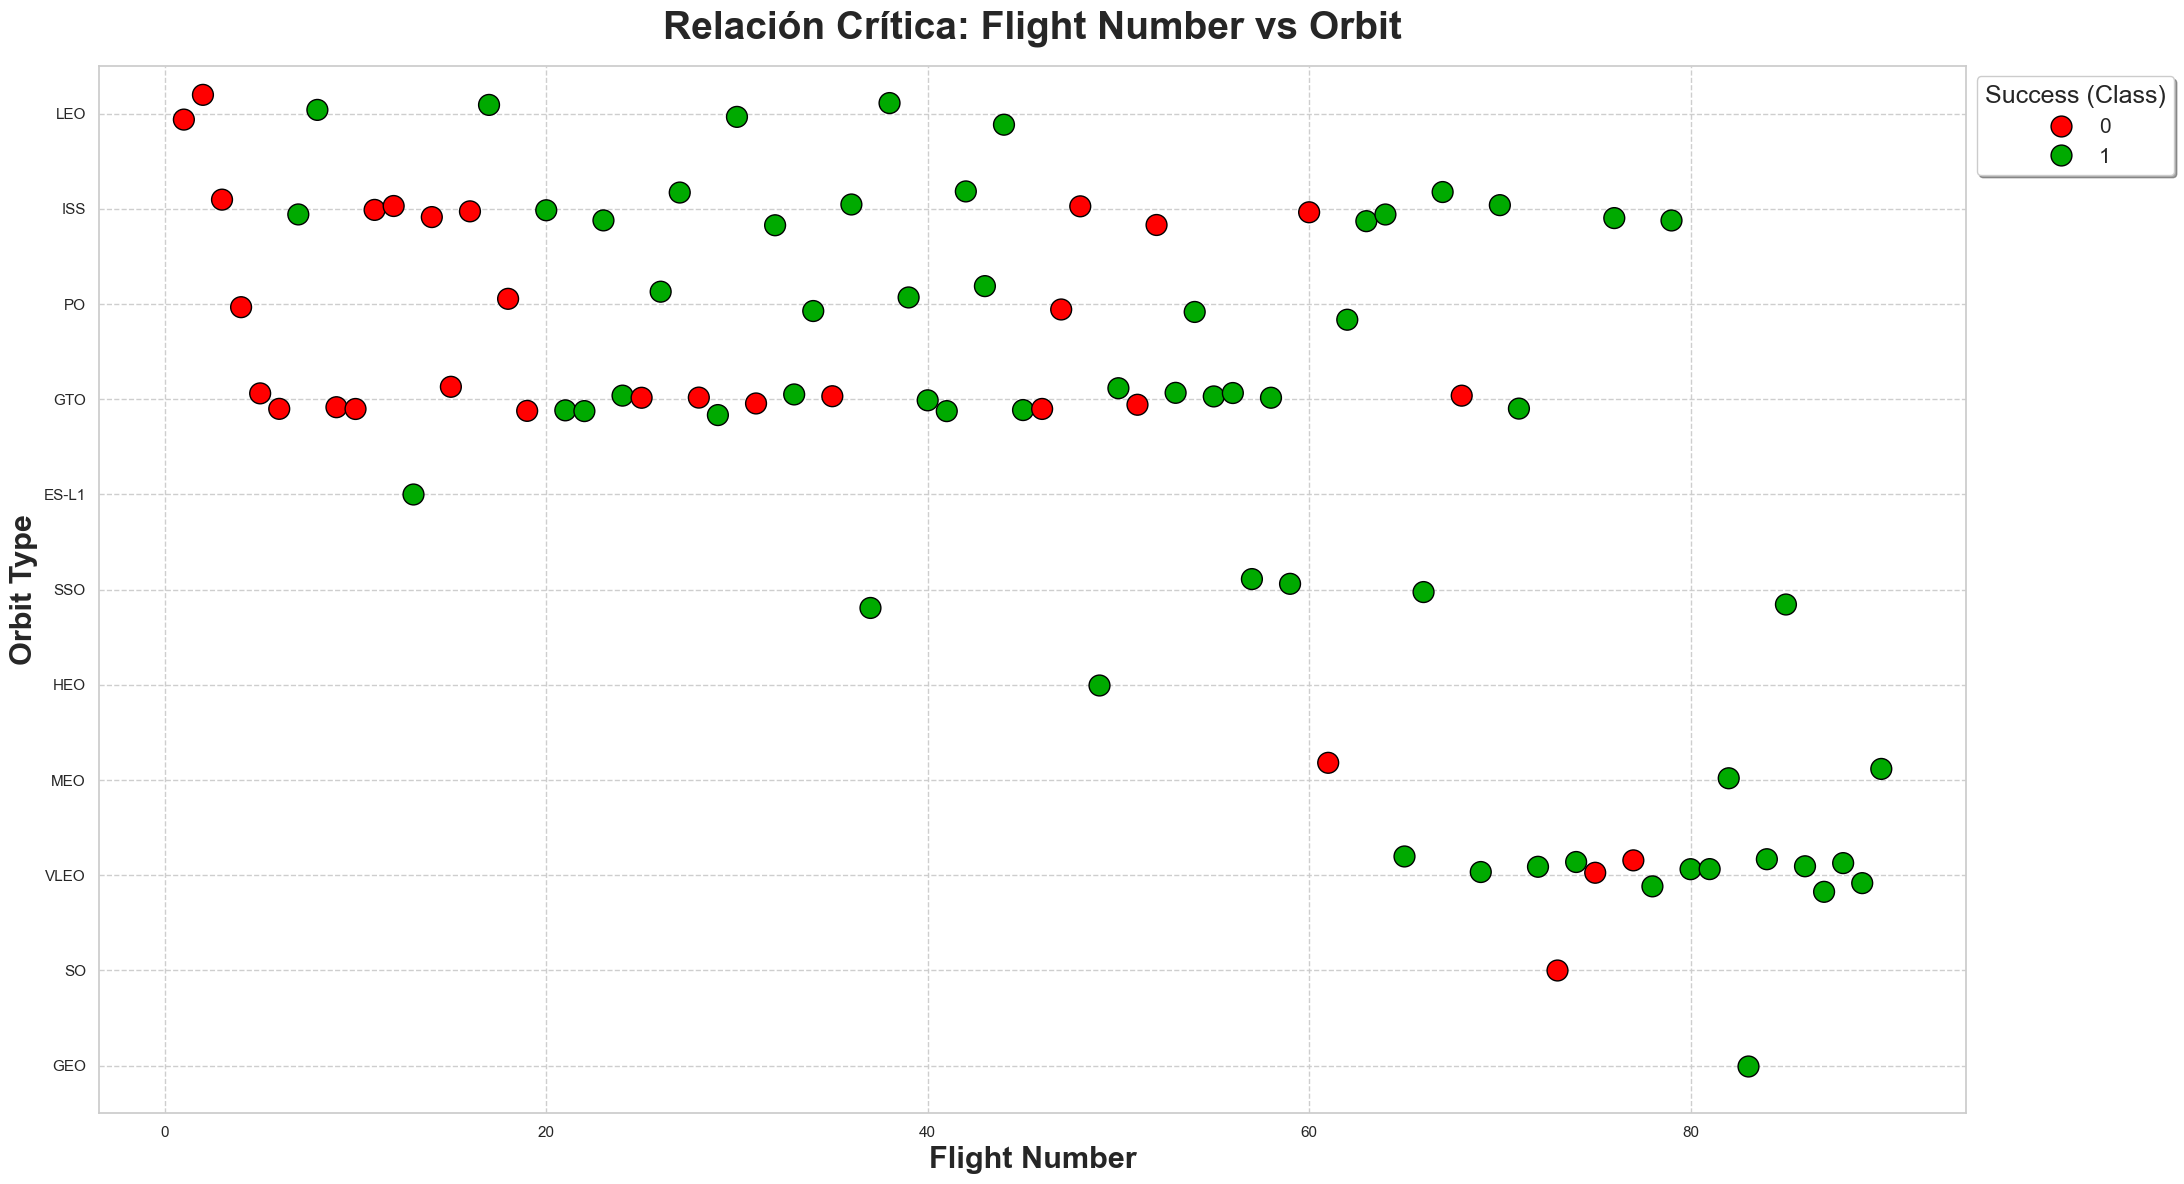

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configuración de figura grande y clara
plt.figure(figsize=(22, 12))
sns.set_theme(style="whitegrid") # Rejilla limpia

# 2. Scatter plot con puntos SÓLIDOS y BORDES
# jitter=0.2 añade un poco de dispersión para que no se pisen
sns.stripplot(
    data=df, 
    x="FlightNumber", 
    y="Orbit", 
    hue="Class", 
    palette={0: "#FF0000", 1: "#00AA00"}, # Rojo puro y Verde sólido para éxito/fallo
    size=15,           # Puntos grandes
    jitter=0.2, 
    alpha=1,           # Opacidad TOTAL (fuera el efecto 'flojo')
    linewidth=1,       # Borde del punto
    edgecolor="black"  # Contorno negro para máximo contraste
)

# 3. Etiquetas de alta visibilidad (PEP8)
plt.title("Relación Crítica: Flight Number vs Orbit", fontsize=28, fontweight='bold', pad=20)
plt.xlabel("Flight Number", fontsize=22, fontweight='bold')
plt.ylabel("Orbit Type", fontsize=22, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.95)
# 4. Ajuste de leyenda para que sea legible
plt.legend(title="Success (Class)", title_fontsize='18', fontsize='15', 
           bbox_to_anchor=(1, 1), loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

You should see that in the LEO orbit the Success appears related to the number of flights; on the other hand, there seems to be no relationship between flight number when in GTO orbit.


### TASK  5: Visualize the relationship between Payload and Orbit type


Similarly, we can plot the Payload vs. Orbit scatter point charts to reveal the relationship between Payload and Orbit type


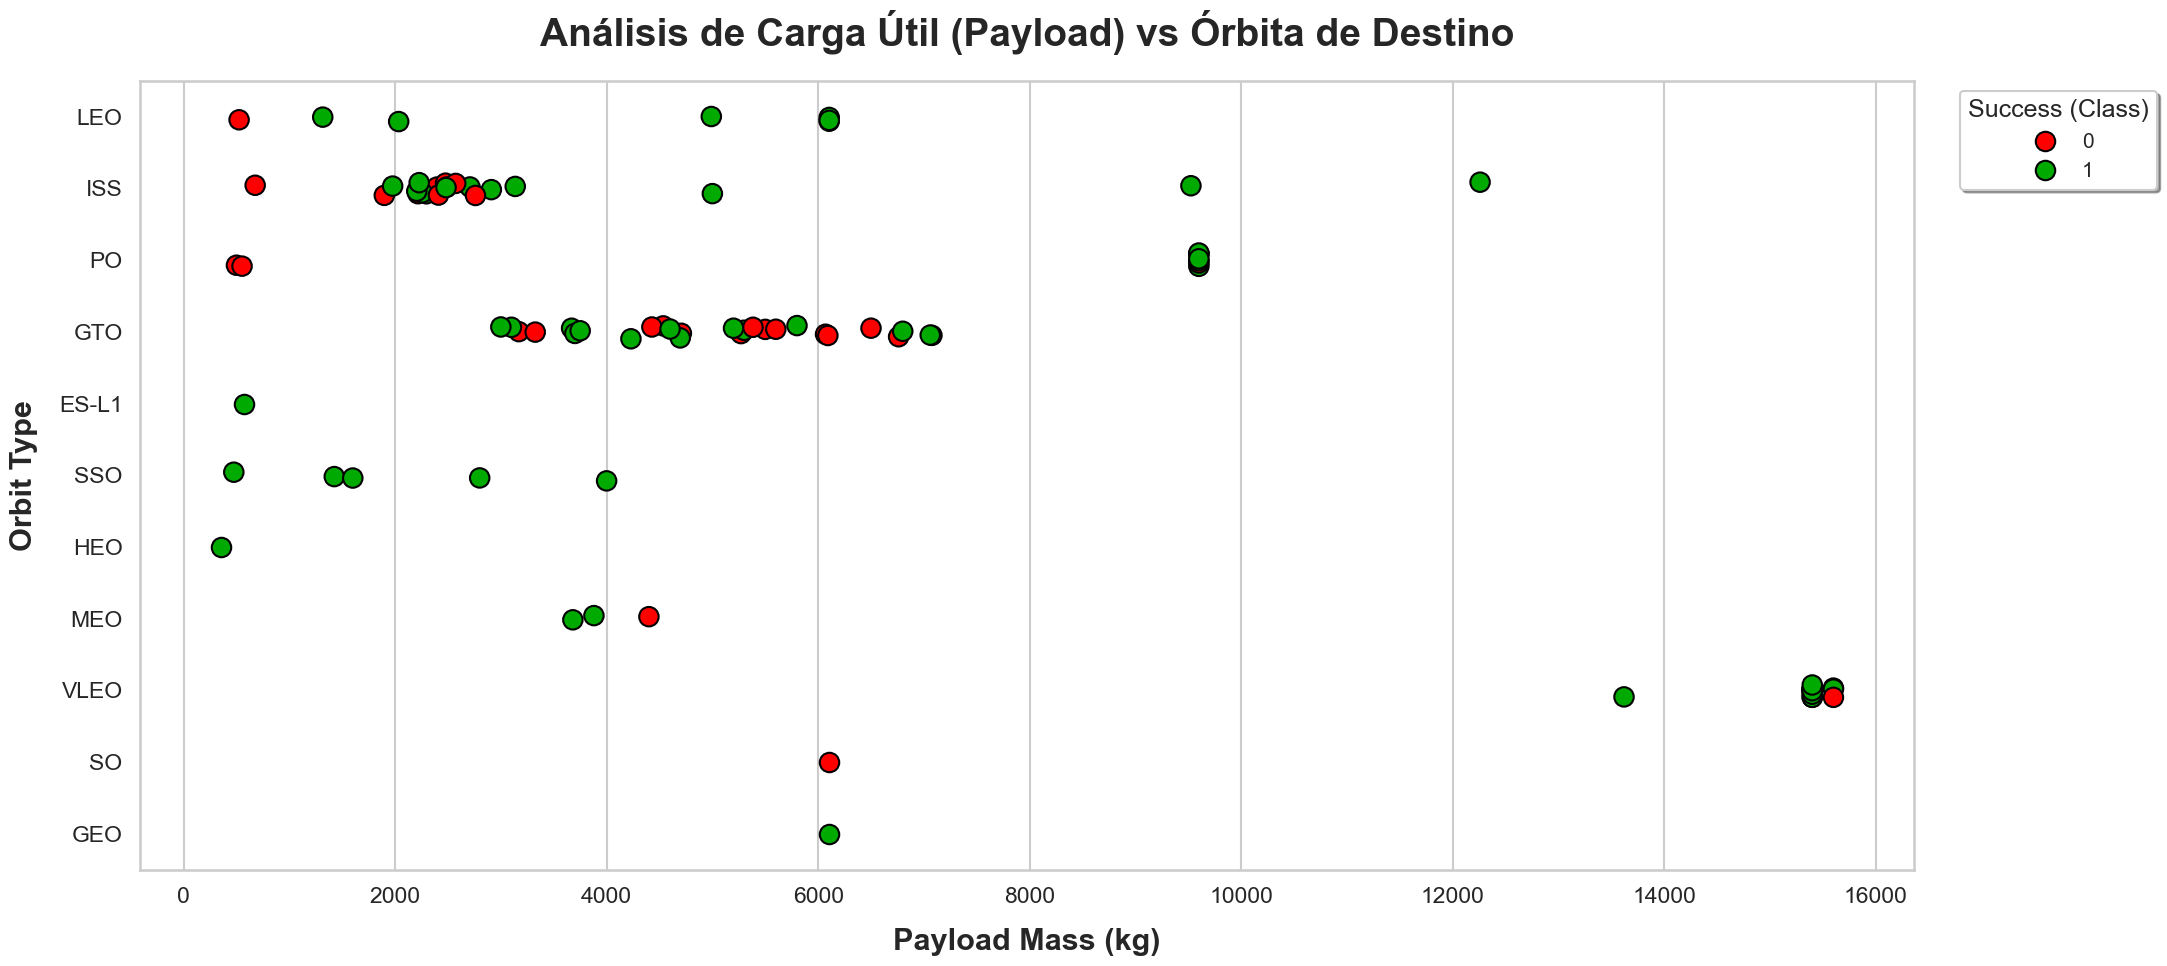

In [24]:
# Plot a scatter point chart with x axis to be Payload and y axis to be the Orbit, and hue to be the class value 1. Configuración de la figura para análisis de alta densidad
plt.figure(figsize=(22, 10))
sns.set_theme(style="whitegrid")
sns.set_context("talk")

# 2. Generación del Scatter Plot (Stripplot para control total)
# x = PayloadMass (Variable independiente física)
# y = Orbit (Variable categórica de destino)
# hue = Class (Variable de éxito/fallo)
sns.stripplot(
    data=df, 
    x="PayloadMass", 
    y="Orbit", 
    hue="Class", 
    palette={0: "#FF0000", 1: "#00AA00"}, # Rojo y Verde puros
    size=14, 
    jitter=0.1,        # Dispersión mínima para ver solapamientos
    alpha=1,           # Opacidad total para máxima nitidez
    linewidth=1.5,     # Borde marcado
    edgecolor="black"  # Contorno negro para resaltar sobre la rejilla
)

# 3. Refinamiento de metadatos (Estándar Pablo / Clean Code)
plt.title("Análisis de Carga Útil (Payload) vs Órbita de Destino", fontsize=28, fontweight='bold', pad=25)
plt.xlabel("Payload Mass (kg)", fontsize=22, fontweight='bold', labelpad=15)
plt.ylabel("Orbit Type", fontsize=22, fontweight='bold', labelpad=15)

# Ajuste de leyenda técnica
plt.legend(title="Success (Class)", title_fontsize='18', fontsize='15', 
           bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

With heavy payloads the successful landing or positive landing rate are more for Polar,LEO and ISS.   

However for GTO we cannot distinguish this well as both positive landing rate and negative landing(unsuccessful mission) are both there here.




### TASK  6: Visualize the launch success yearly trend


You can plot a line chart with x axis to be <code>Year</code> and y axis to be average success rate, to get the average launch success trend. 


The function will help you get the year from the date:


In [25]:
# A function to Extract years from the date 
year=[]
def Extract_year(date):
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
    

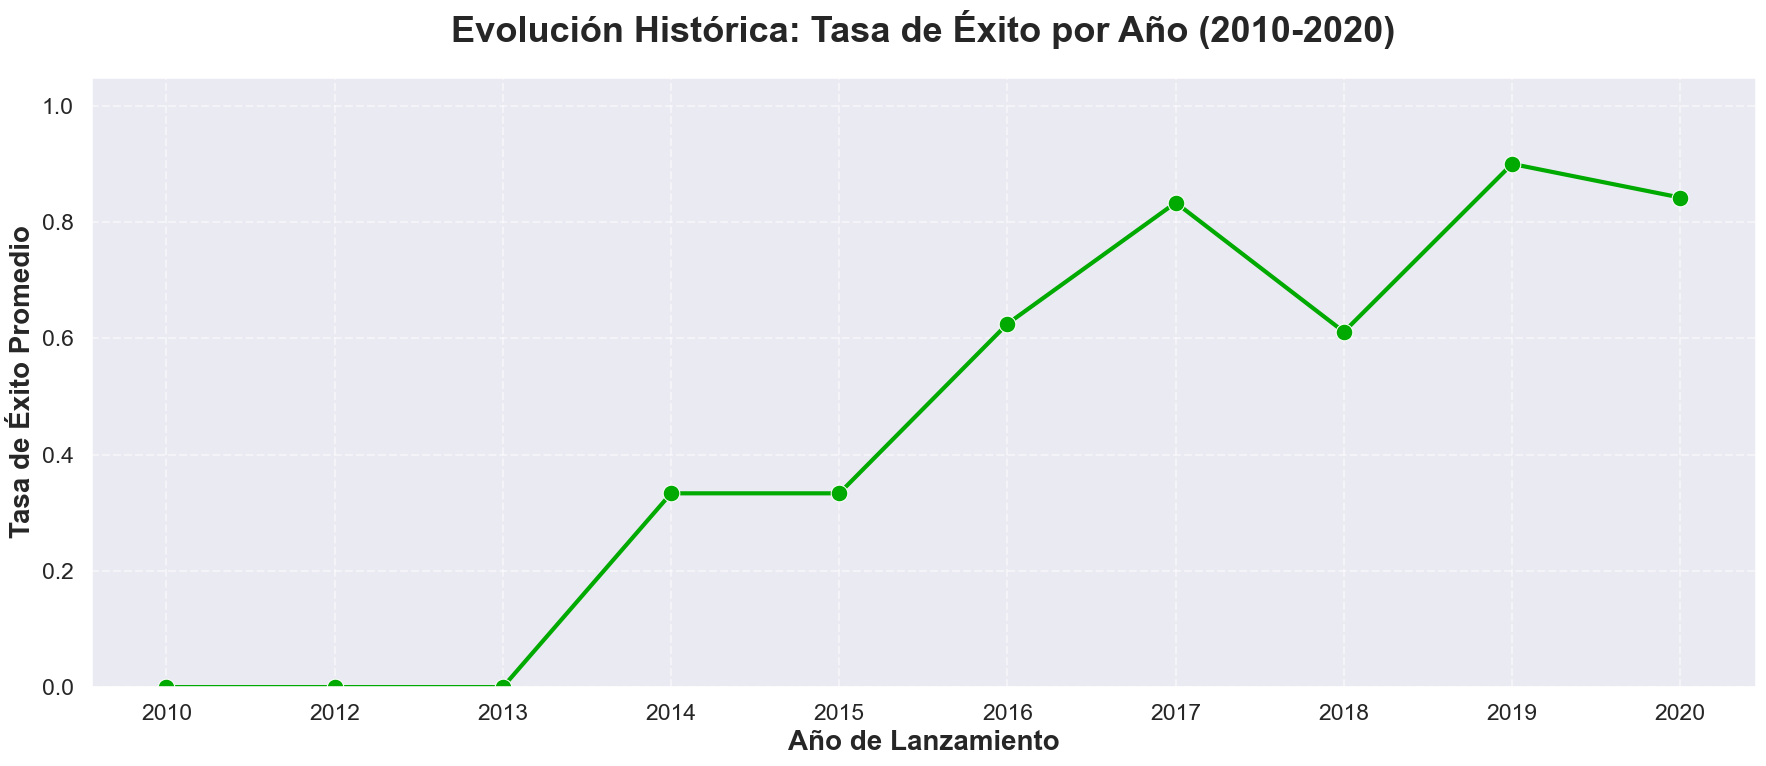

In [27]:
# Plot a line chart with # Añadimos la columna temporal al DataFrame
df["Year"] = Extract_year(df)

# 2. Cálculo de la tasa de éxito por año (Success Rate)
# Agrupamos por año y calculamos la media de la columna 'Class'
df_yearly_success = df.groupby("Year")["Class"].mean().reset_index()

# 3. Configuración de estética de alta resolución
sns.set_theme(style="darkgrid")
sns.set_context("talk")
plt.figure(figsize=(18, 8))

# 4. Generación del Line Chart
# Marcadores sólidos y línea gruesa para evitar el efecto 'flojo'
sns.lineplot(
    data=df_yearly_success, 
    x="Year", 
    y="Class", 
    marker="o", 
    markersize=12, 
    linewidth=3, 
    color="#00AA00" # Verde sólido para representar éxito acumulado
)

# 5. Refinamiento de metadatos (Estilo Docente Senior)
plt.title("Evolución Histórica: Tasa de Éxito por Año (2010-2020)", fontsize=26, fontweight='bold', pad=25)
plt.xlabel("Año de Lanzamiento", fontsize=20, fontweight='bold')
plt.ylabel("Tasa de Éxito Promedio", fontsize=20, fontweight='bold')
plt.ylim(0, 1.05) # Aseguramos que el eje Y cubra el rango del 0% al 100%

# Añadir rejilla secundaria para precisión de lectura
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


You can observe that the success rate since 2013 kept increasing till 2017 (stable in 2014) and after 2015 it started increasing.


## Features Engineering 


By now, you should obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction in the future module.


In [28]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


 ### TASK  7: Create dummy variables to categorical columns


Use the function <code>get_dummies</code> and <code>features</code> dataframe to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. Assign the value to the variable <code>features_one_hot</code>, display the results using the method head. Your result dataframe must include all features including the encoded ones.


In [29]:

# 1. Definición de las columnas categóricas para transformación
categorical_columns = ['Orbit', 'LaunchSite', 'LandingPad', 'Serial']

# 2. Aplicación de get_dummies
# El parámetro 'columns' permite aplicar la transformación solo a las deseadas
# manteniendo el resto del dataframe intacto (como PayloadMass o FlightNumber)
features_one_hot = pd.get_dummies(
    features, 
    columns=categorical_columns,
    prefix=categorical_columns # Mantiene una nomenclatura profesional y clara
)

# 3. Visualización de los resultados (Primeras 5 filas)
# Nota: Verás que el número de columnas (shape[1]) aumentará significativamente
print(f"Dimensiones originales: {features.shape}")
print(f"Nuevas dimensiones tras One-Hot Encoding: {features_one_hot.shape}")
print("\n--- Vista previa de features_one_hot ---")
features_one_hot.head()

Dimensiones originales: (90, 12)
Nuevas dimensiones tras One-Hot Encoding: (90, 80)

--- Vista previa de features_one_hot ---


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


### TASK  8: Cast all numeric columns to `float64`


Now that our <code>features_one_hot</code> dataframe only contains numbers cast the entire dataframe to variable type <code>float64</code>


In [30]:
# HINT: use astype function
# Cast the entire dataframe to float64 as requested
# Using .astype('float64') ensures all numerical features are in the 
# high-precision format required for physical modeling and ML stability.
features_one_hot = features_one_hot.astype('float64')

# Display the result and verify the dtypes
print("--- Tipos de datos actualizados (Dtypes) ---")
print(features_one_hot.dtypes.unique()) # Debería mostrar solo [dtype('float64')]

print("\n--- Vista previa de features_one_hot (Float64) ---")
features_one_hot.head()

--- Tipos de datos actualizados (Dtypes) ---
[dtype('float64')]

--- Vista previa de features_one_hot (Float64) ---


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


We can now export it to a <b>CSV</b> for the next section,but to make the answers consistent, in the next lab we will provide data in a pre-selected date range. 


<code>features_one_hot.to_csv('dataset_part_3.csv', index=False)</code>


In [31]:
features_one_hot.to_csv('dataset_part_3.csv', index=False)

## Authors


<a href="https://www.linkedin.com/in/joseph-s-50398b136/">Joseph Santarcangelo</a> has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.


<a href="https://www.linkedin.com/in/nayefaboutayoun/">Nayef Abou Tayoun</a> is a Data Scientist at IBM and pursuing a Master of Management in Artificial intelligence degree at Queen's University.


## Change Log


| Date (YYYY-MM-DD) | Version | Changed By | Change Description      |
| ----------------- | ------- | ---------- | ----------------------- |
| 2021-10-12        | 1.1     | Lakshmi Holla     | Modified markdown |
| 2020-09-20        | 1.0     | Joseph     | Modified Multiple Areas |
| 2020-11-10       | 1.1    | Nayef      | updating the input data |


Copyright © 2020 IBM Corporation. All rights reserved.
